## Banking Chatbot Query-Intent Classification Using Naive Bayes

The objective of this project is to classify banking customer queries into their correct intent category using the Naive Bayes algorithm.

## Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

## Load dataset

In [2]:
df = pd.read_csv("dev.csv")
df.head()

,text,label,label_text
0,How do I locate my card?,11,card_arrival
1,"I still have not received my new card, I order...",11,card_arrival
2,I ordered a card but it has not arrived. Help ...,11,card_arrival
3,Is there a way to know when my card will arrive?,11,card_arrival
4,My card has not arrived yet.,11,card_arrival


## Basic data understanding

In [3]:
df.shape

(3080, 3)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3080 entries, 0 to 3079
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        3080 non-null   object
 1   label       3080 non-null   int64 
 2   label_text  3080 non-null   object
dtypes: int64(1), object(2)
memory usage: 72.3+ KB


In [5]:
df.describe()

,label
count,3080.00000
mean,38.00000
std,22.22972
min,0.00000
25%,19.00000
50%,38.00000
75%,57.00000
max,76.00000


In [6]:
df.isnull().sum()

text          0
label         0
label_text    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

## Data cleaning

In [8]:
# check empty queries
(df["text"].str.strip() == "").sum()

np.int64(0)

In [9]:
# drop duplicate rows and missing values, if any
df = df.drop_duplicates()
df = df.dropna()

df.shape

(3080, 3)

## EDA

### Distribution of banking intents (top 15)

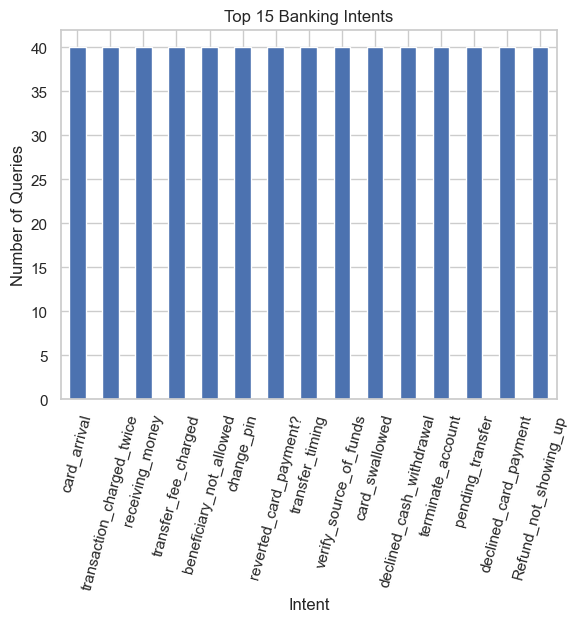

In [10]:
df["label_text"].value_counts().head(15).plot(kind="bar")

plt.title("Top 15 Banking Intents")
plt.xlabel("Intent")
plt.ylabel("Number of Queries")
plt.xticks(rotation=75)

plt.show()

### Share of top 10 intents

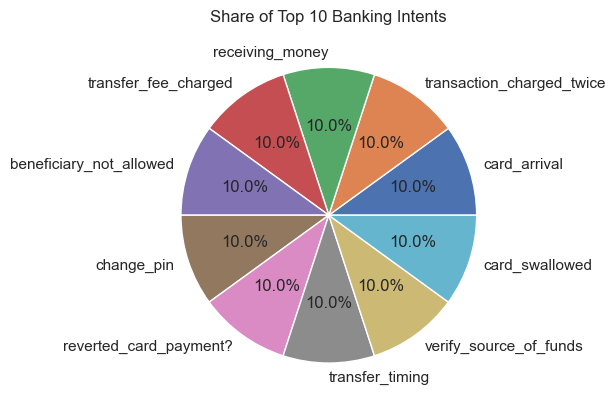

In [11]:
df["label_text"].value_counts().head(10).plot(kind="pie", autopct="%1.1f%%")

plt.title("Share of Top 10 Banking Intents")
plt.ylabel("")
plt.show()

### Most frequent words in customer queries

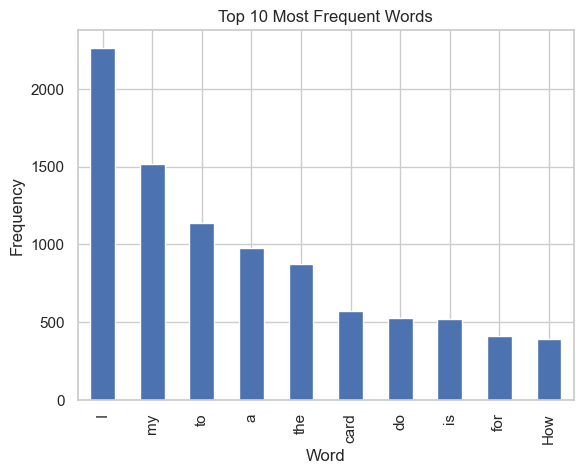

In [12]:
df["text"].str.split().explode().value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Most Frequent Words")
plt.xlabel("Word")
plt.ylabel("Frequency")

plt.show()

### Query length distribution

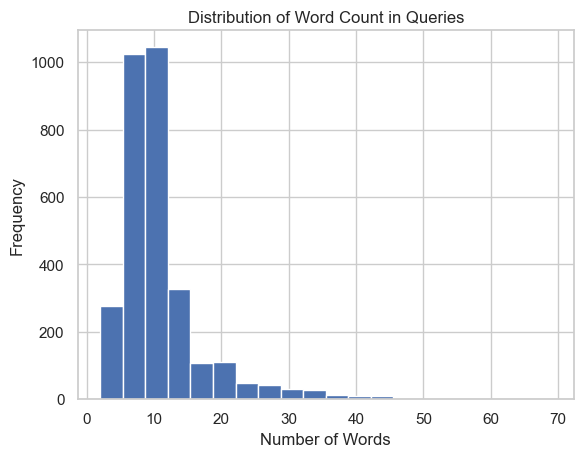

In [13]:
word_count = df["text"].apply(lambda x: len(x.split()))

plt.hist(word_count, bins=20)

plt.title("Distribution of Word Count in Queries")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

### Insights

* The dataset has 77 banking intents and they are fairly balanced, around 40 queries each.
* Words like "card", "my" and "account" are among the most frequent words in the queries.
* Most customer queries are short, usually under 15 words.

## Feature and target preparation

In [14]:
x = df["text"]
y = df["label_text"]

## Convert text into numbers

Naive Bayes needs numbers, not raw sentences. So `CountVectorizer` is used to convert each query into a vector of word counts. This is not TF-IDF, it simply counts how many times each word appears.

In [15]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [16]:
cv = CountVectorizer()

x_train = cv.fit_transform(x_train)
x_test = cv.transform(x_test)

x_train.shape

(2464, 1326)

## Naive Bayes model

In [17]:
bayes = MultinomialNB()
bayes.fit(x_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


## Prediction

In [18]:
y_pred = bayes.predict(x_test)

## Evaluation

In [19]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Precision Score:", precision_score(y_test, y_pred, average="weighted"))
print("Recall Score:", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))

Accuracy Score: 0.7224025974025974
Precision Score: 0.7822835504725306
Recall Score: 0.7224025974025974
F1 Score: 0.7202493212450024


In [20]:
print(classification_report(y_test, y_pred))

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.88      1.00      0.93         7
                                activate_my_card       0.86      0.67      0.75         9
                                       age_limit       0.86      1.00      0.92         6
                         apple_pay_or_google_pay       0.78      1.00      0.88         7
                                     atm_support       1.00      0.56      0.71         9
                                automatic_top_up       1.00      0.80      0.89        10
         balance_not_updated_after_bank_transfer       0.58      0.70      0.64        10
balance_not_updated_after_cheque_or_cash_deposit       1.00      0.71      0.83         7
                         beneficiary_not_allowed       0.50      0.38      0.43         8
                                 cancel_transfer       0.86      0.75      0.80         8
         

### Confusion matrix

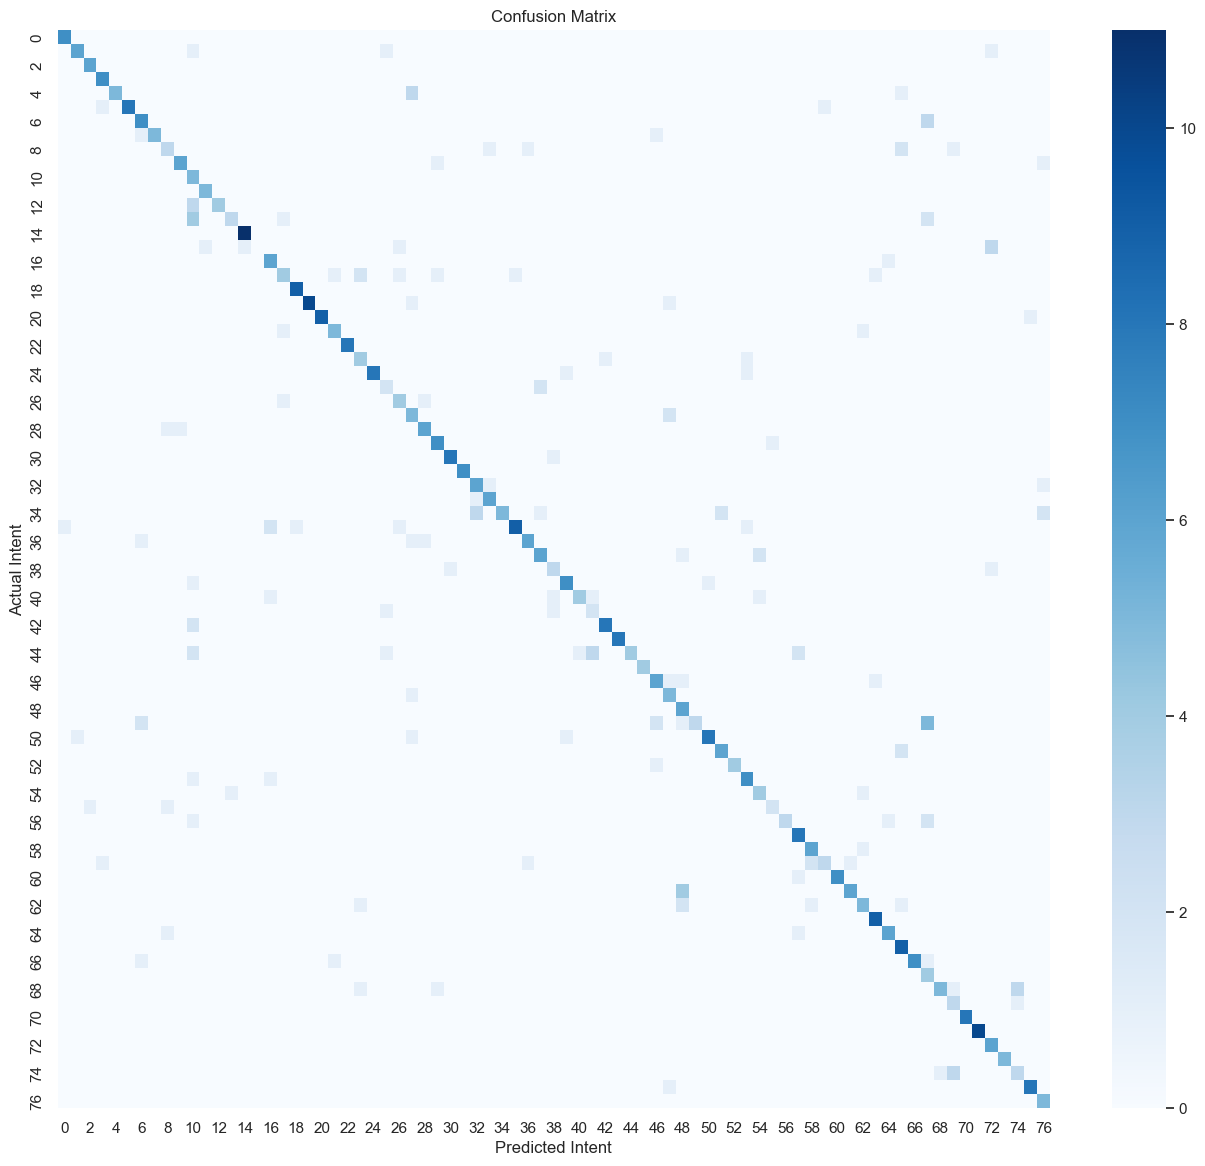

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Intent")
plt.ylabel("Actual Intent")

plt.show()

## Final result

In [22]:
print("Final Accuracy:", accuracy_score(y_test, y_pred))

Final Accuracy: 0.7224025974025974


## Sample prediction

In [23]:
new_query = ["I forgot my PIN"]

new_query_vector = cv.transform(new_query)
prediction = bayes.predict(new_query_vector)

print("Predicted Intent:", prediction[0])

Predicted Intent: pin_blocked


## Conclusion

A MultinomialNB model was trained on Bag-of-Words features (created using CountVectorizer) to classify banking customer queries into 77 intents. The model achieved an accuracy of about 72% on the test data, as shown in the evaluation section above, and correctly predicted "pin_blocked" as the intent for the sample query "I forgot my PIN".